Task 2: Data Engineering and Preparation

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD DATASETS
df_patients = pd.read_csv('eye_cancer_patients.csv')
df_gdp = pd.read_csv('GDP_indicator.csv', skiprows=4) 

# 2. DATA RESHAPING (Wide-to-Long for GDP Indicator)
target_countries = ['France', 'Brazil', 'India']
df_gdp_filtered = df_gdp[df_gdp['Country Name'].isin(target_countries)].copy()

df_gdp_long = df_gdp_filtered.melt(
    id_vars=['Country Name'], 
    value_vars=['2019', '2020', '2021', '2022', '2023'],
    var_name='Year', 
    value_name='GDP_Expenditure_Percent'
)
df_gdp_long['Year'] = df_gdp_long['Year'].astype(int)

# 3. NOISY DATA HANDLING & PRE-PROCESSING
df_patients = df_patients[df_patients['Country'].isin(target_countries)].copy()
df_patients['Date_of_Diagnosis'] = pd.to_datetime(df_patients['Date_of_Diagnosis'])
df_patients['Year'] = df_patients['Date_of_Diagnosis'].dt.year

# Standardize text to prevent "Melanoma" vs "melanoma" noise
df_patients['Cancer_Type'] = df_patients['Cancer_Type'].str.strip().str.title()
df_patients['Outcome_Status'] = df_patients['Outcome_Status'].str.strip()

# 4. MISSING DATA HANDLING (Informative Imputation)
df_patients['Genetic_Markers'] = df_patients['Genetic_Markers'].replace('None', 'Not Tested')
df_patients['Genetic_Markers'] = df_patients['Genetic_Markers'].fillna('Not Tested')

# 5. OUTLIER DETECTION (IQR Method)
# Identifying biological outliers in Age and Survival
def handle_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= (Q1 - 1.5 * IQR)) & (df[col] <= (Q3 + 1.5 * IQR))]

df_patients = df_patients[df_patients['Age'] > 0] 

# 6. MERGING MACRO AND MICRO DATA
df_merged = pd.merge(
    df_patients, df_gdp_long, 
    left_on=['Country', 'Year'], 
    right_on=['Country Name', 'Year'], 
    how='inner'
).drop(columns=['Country Name'])

# 7. STRATIFIED SAMPLING
def get_balanced_sample(df, total_n=1510):
    countries = ['France', 'Brazil', 'India']
    n_per_country = total_n // len(countries)
    remainder = total_n % len(countries)
    samples = []
    for i, country in enumerate(countries):
        target = n_per_country + (1 if i < remainder else 0)
        subset = df[df['Country'] == country]
        replace_bool = len(subset) < target
        samples.append(subset.sample(n=target, replace=replace_bool, random_state=42))
    return pd.concat(samples)

df_1510 = get_balanced_sample(df_merged)

# 8. FEATURE ENGINEERING & ORDERING
tier_map = {'France': 'High-Spending', 'Brazil': 'Mid-Spending', 'India': 'Low-Spending'}
df_1510['Economic_Tier'] = df_1510['Country'].map(tier_map)

# Enforce logical order: High -> Mid -> Low
tier_order = ['High-Spending', 'Mid-Spending', 'Low-Spending']
df_1510['Economic_Tier'] = pd.Categorical(df_1510['Economic_Tier'], categories=tier_order, ordered=True)
df_final = df_1510.sort_values('Economic_Tier')

# 9. DATA AGGREGATION (For Strategic Overview)
# Creating a summary for the auditor's review
aggregation_summary = df_final.groupby(['Economic_Tier', 'Genetic_Markers']).agg({
    'Survival_Time_Months': ['mean', 'std'],
    'Age': 'mean',
    'Patient_ID': 'count'
}).reset_index()

# 10. SAVE FINAL DATASET
df_final.to_csv('Eye_Cancer_Merged_data_set.csv', index=False)
aggregation_summary.to_csv('aggregated_survival_summary.csv', index=False)

print("Task 2 Engineering Complete. Files saved.")

Task 2 Engineering Complete. Files saved.


/var/folders/mp/y7d1n9sn46544llv9kqw2g440000gn/T/ipykernel_32648/2678255169.py:81: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Task 3:  Exploratory Visualization 

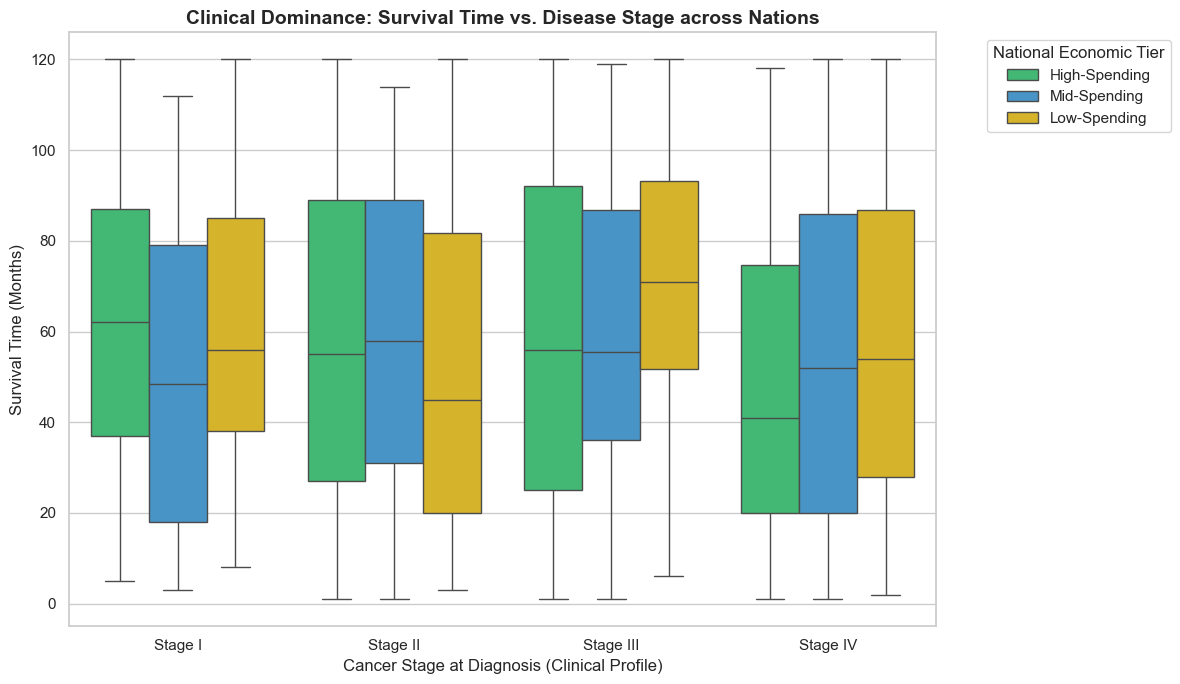

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('Eye_Cancer_Merged_data_set.csv')

# 2. Set the professional style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 3. Create the Box Plot
sns.boxplot(
    data=df, 
    x='Stage_at_Diagnosis', 
    y='Survival_Time_Months', 
    hue='Economic_Tier',
    order=['Stage I', 'Stage II', 'Stage III', 'Stage IV'],
    palette={"High-Spending": "#2ecc71", "Mid-Spending": "#3498db", "Low-Spending": "#f1c40f"}
)

# 4. Professional Labels and Titles
plt.title('Clinical Dominance: Survival Time vs. Disease Stage across Nations', fontsize=14, fontweight='bold')
plt.xlabel('Cancer Stage at Diagnosis (Clinical Profile)', fontsize=12)
plt.ylabel('Survival Time (Months)', fontsize=12)
plt.legend(title='National Economic Tier', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

/var/folders/mp/y7d1n9sn46544llv9kqw2g440000gn/T/ipykernel_30935/2017941845.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diag_gap = df.groupby(['Economic_Tier', 'Genetic_Markers']).size().unstack()


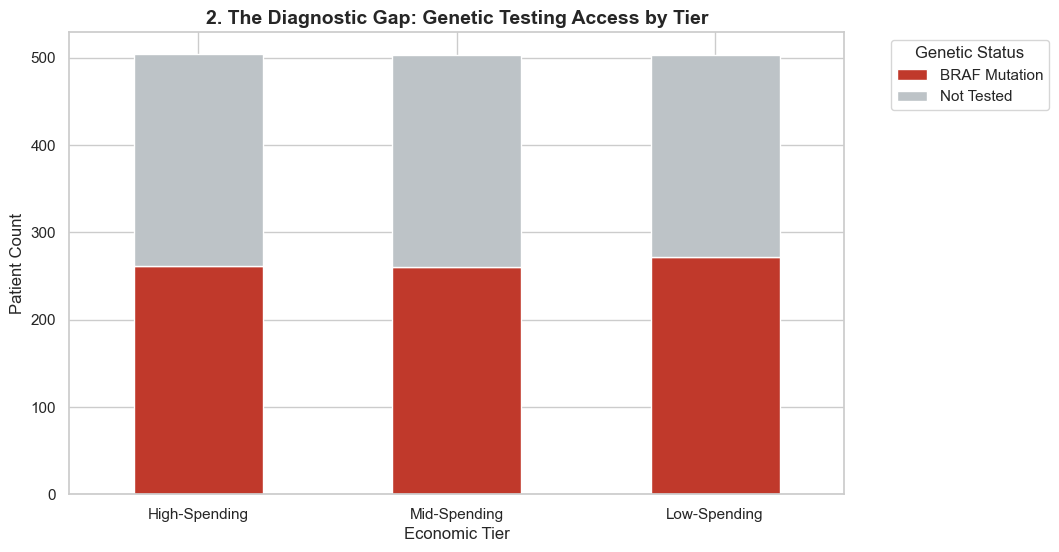

In [3]:
# Prepare data for stacked bar
diag_gap = df.groupby(['Economic_Tier', 'Genetic_Markers']).size().unstack()

# Plot
diag_gap.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#c0392b', '#bdc3c7'])
plt.title('2. The Diagnostic Gap: Genetic Testing Access by Tier', fontsize=14, fontweight='bold')
plt.xlabel('Economic Tier')
plt.ylabel('Patient Count')
plt.xticks(rotation=0)
plt.legend(title='Genetic Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/var/folders/mp/y7d1n9sn46544llv9kqw2g440000gn/T/ipykernel_30935/252296874.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


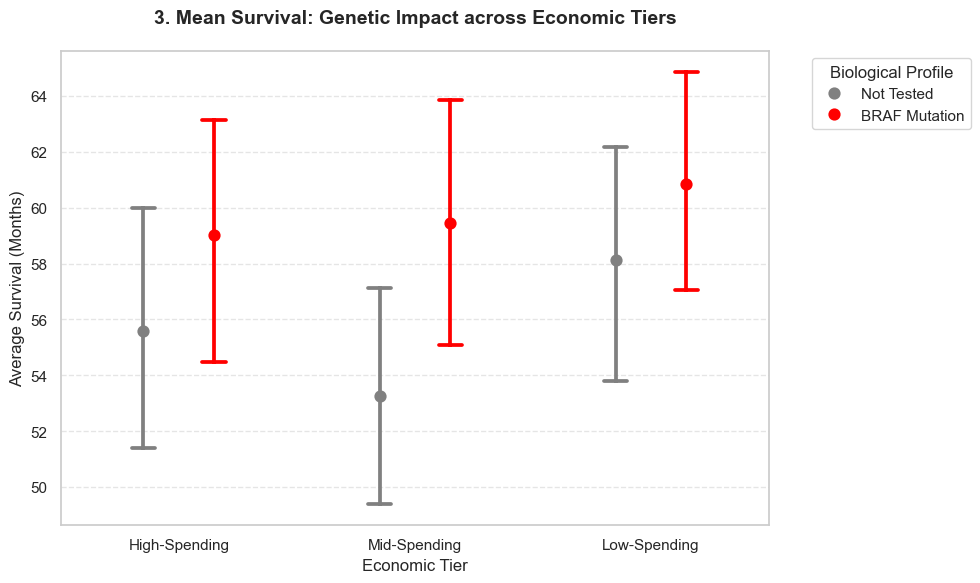

In [ ]:

genetic_palette = {
    "BRAF Mutation": "red", 
    "Not Tested": "grey"
}

plt.figure(figsize=(10, 6))
sns.pointplot(
    x='Economic_Tier', 
    y='Survival_Time_Months', 
    hue='Genetic_Markers', 
    data=df, 
    join=False, 
    capsize=.1, 
    palette=genetic_palette,
    dodge=0.3 
)
plt.title('3. Mean Survival: Genetic Impact across Economic Tiers', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Average Survival (Months)', fontsize=12)
plt.xlabel('Economic Tier', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Biological Profile', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

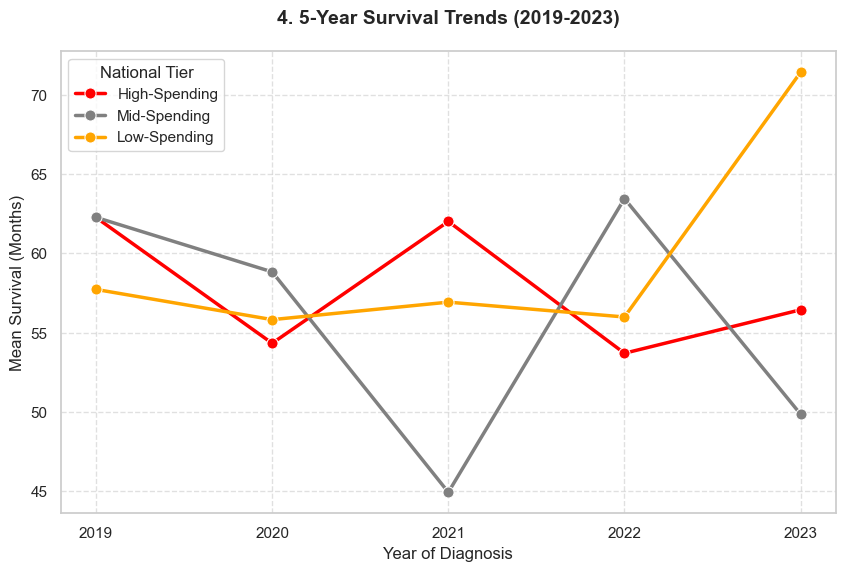

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

custom_colors = {
    "High-Spending": "red", 
    "Mid-Spending": "grey", 
    "Low-Spending": "orange"
}
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='Year', 
    y='Survival_Time_Months', 
    hue='Economic_Tier', 
    data=df, 
    marker='o', 
    palette=custom_colors, 
    errorbar=None,
    linewidth=2.5,
    markersize=8
)
plt.title('4. 5-Year Survival Trends (2019-2023)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Mean Survival (Months)', fontsize=12)
plt.xlabel('Year of Diagnosis', fontsize=12)
plt.xticks([2019, 2020, 2021, 2022, 2023]) 
plt.grid(True, linestyle='--', alpha=0.6) 
plt.legend(title='National Tier', frameon=True)

plt.show()

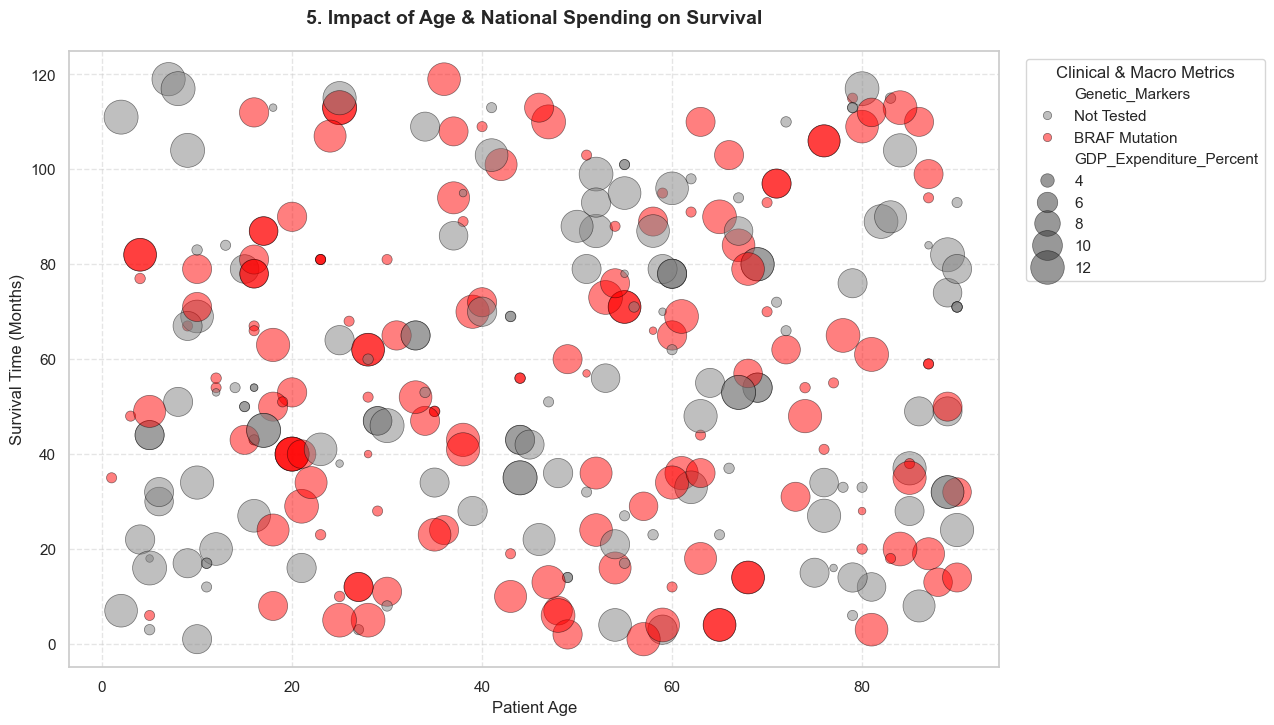

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the sample remains consistent for your report
df_sample = df.sample(300, random_state=42)
bubble_palette = {
    "BRAF Mutation": "red", 
    "Not Tested": "grey"
}

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='Age', 
    y='Survival_Time_Months', 
    size='GDP_Expenditure_Percent', 
    hue='Genetic_Markers', 
    sizes=(30, 600),         
    alpha=0.5,                
    data=df_sample, 
    palette=bubble_palette,
    edgecolor='black',      
    linewidth=0.5
)
plt.title('5. Impact of Age & National Spending on Survival', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Patient Age', fontsize=12)
plt.ylabel('Survival Time (Months)', fontsize=12)

# Moving the legend outside so it doesn't cover the bubbles
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Clinical & Macro Metrics')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

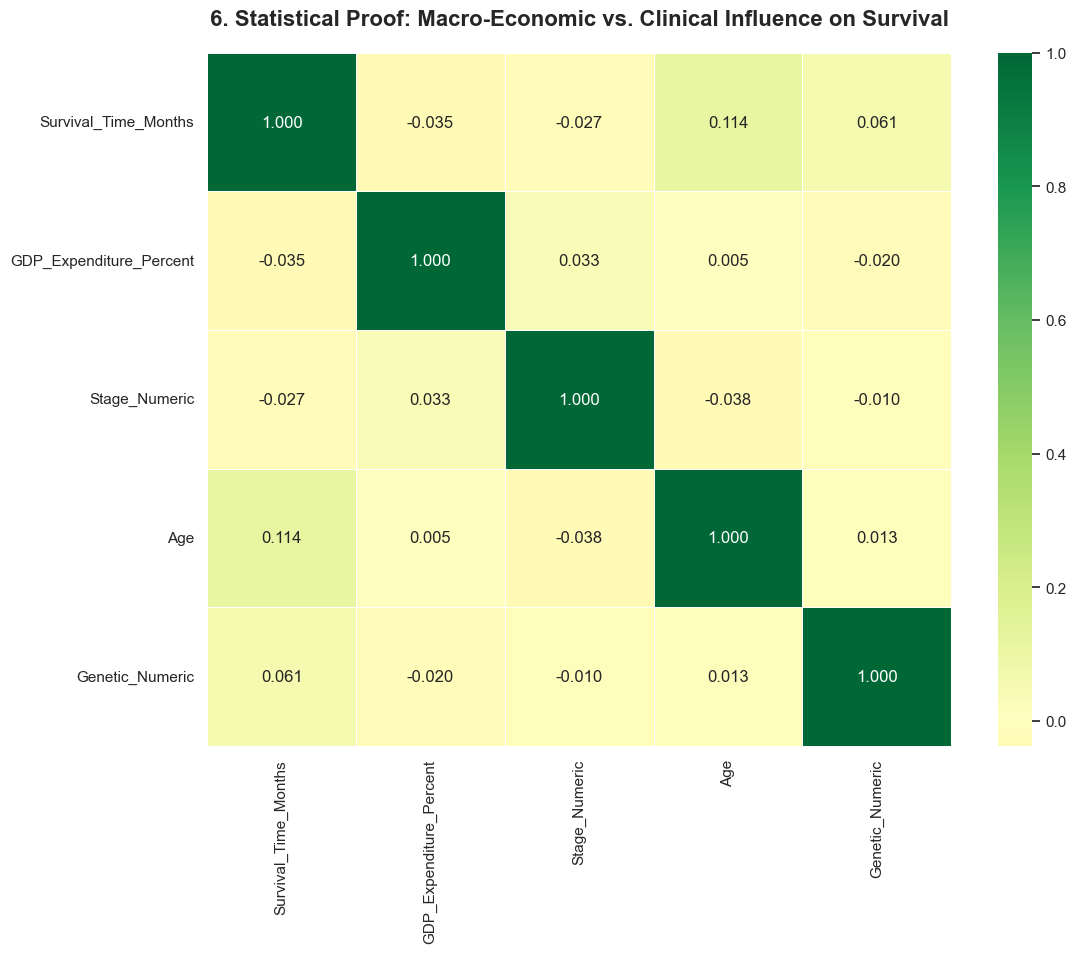

In [ ]:

# Mapping Genetics: 1 for Mutation (High Risk), 0 for Not Tested (Baseline)
df['Genetic_Numeric'] = df['Genetic_Markers'].map({'BRAF Mutation': 1, 'Not Tested': 0})

stage_map = {'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4}
df['Stage_Numeric'] = df['Stage_at_Diagnosis'].map(stage_map)

# --- STEP 2: Correlation Calculation ---
plt.figure(figsize=(12, 9))
cols_to_correlate = [
    'Survival_Time_Months', 
    'GDP_Expenditure_Percent', 
    'Stage_Numeric',            
    'Age',                     
    'Genetic_Numeric'           
]

corr_matrix = df[cols_to_correlate].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".3f", linewidths=0.5)

plt.title('6. Statistical Proof: Macro-Economic vs. Clinical Influence on Survival', 
          fontsize=16, fontweight='bold', pad=20)

plt.show()

Task 4:Geospatial visualizations

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Load Data
df = pd.read_csv('Eye_Cancer_Merged_data_set.csv')

# 2. Strategic Aggregation
geo_df = df.groupby('Country').agg({
    'Survival_Time_Months': 'mean',
    'GDP_Expenditure_Percent': 'mean',
    'Patient_ID': 'count'
}).reset_index()

# 3. Create the Map
fig_geo = px.choropleth(
    geo_df,
    locations="Country",
    locationmode="country names",
    color="Survival_Time_Months",
    hover_name="Country",
    title="<b>4.2 The Postcode Lottery: Global Inequity in Clinical Outcomes</b>",
    color_continuous_scale="Viridis", 
    labels={'Survival_Time_Months': 'Months'}
)

# 4. ADVANCED BORDER & GEOGRAPHY STYLING
fig_geo.update_geos(
    visible=True, 
    resolution=50,
    showcountries=True, 
    countrycolor="#2c3e50",      
    countrywidth=0.8,           
    showcoastlines=True, 
    coastlinecolor="#2c3e50",    
    showland=True, 
    landcolor="#f8f9f9",        
    showocean=True, 
    oceancolor="#f0f8ff",       
    projection_type='natural earth' 
)

fig_geo.update_layout(
    title_font_size=24,
    title_font_color="#1a2a3a",
    margin=dict(l=0, r=0, t=80, b=0),
    coloraxis_colorbar=dict(
        title="Months",
        thicknessmode="pixels", thickness=25,
        lenmode="fraction", len=0.8,
        yanchor="middle", y=0.5,
        ticks="outside"
    )
)

fig_geo.show()

/var/folders/mp/y7d1n9sn46544llv9kqw2g440000gn/T/ipykernel_32648/2343328726.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



Task 4:Scenario-based visual comparison

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# Scenario 1: The Power of Early Detection (Even with Low Budget)
s1_filter = (df['Economic_Tier'] == 'Low-Spending') & (df['Stage_at_Diagnosis'] == 'Stage I')
s1_mean = df[s1_filter]['Survival_Time_Months'].mean()

# Scenario 2: The Limitation of Wealth (Even with High Budget)
s2_filter = (df['Economic_Tier'] == 'High-Spending') & (df['Stage_at_Diagnosis'] == 'Stage IV')
s2_mean = df[s2_filter]['Survival_Time_Months'].mean()

fig_scenario = go.Figure()

fig_scenario.add_trace(go.Bar(
    x=['Scenario A: Low Budget + Stage I'],
    y=[s1_mean],
    name='Clinical Advantage',
    marker_color="#19c8e7", # Green for survival success
    text=[f"{s1_mean:.1f} Mo"],
    textposition='auto'
))

fig_scenario.add_trace(go.Bar(
    x=['Scenario B: High Budget + Stage IV'],
    y=[s2_mean],
    name='Macro-Economic Limitation',
    marker_color="#c8ce4d", # Red for biological risk
    text=[f"{s2_mean:.1f} Mo"],
    textposition='auto'
))


fig_scenario.update_layout(
    title="<b>4.3 Scenario Analysis: Clinical Profile vs. National Treasury</b>",
    yaxis_title="Average Survival (Months)",
    template="plotly_white",
    height=500,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig_scenario.add_hline(y=df['Survival_Time_Months'].mean(), 
                       line_dash="dot", 
                       annotation_text=f"Cohort Avg: {df['Survival_Time_Months'].mean():.1f} Mo", 
                       line_color="grey")

fig_scenario.show()